# Analiza scenarija: "Božji usamljeni ljudi"

Računarska analiza jezika protagonista u četiri scenarija Pola Šrejdera, urađena za master rad
*Božji usamljeni ljudi: računarska analiza jezika protagonista u scenarijima Pola Šrejdera*
(Univerzitet Singidunum, 2026)

Korpus čine iskazi četvorice protagonista: Trevisa Bikla (*Taksista*, 1976), Džona LeTura (*Fatalna nesanica*, 1992), Ernsta Tolera (*Iskušenik*, 2017) i Vilijama Tela (*Kockar*, 2021). Svaki iskaz je obeležen narativnim modom - dijalog ili narracija - i to je osnovna osa poređenja u celom radu. Ukupno 1.158 iskaza i oko 13.700 tokena.

Notebook obuhvata sedam korata: spajanje parsiranih scenarija u jedinstven korpus, ocenjivanje sentimenta i emocija transformerskim modelima, ocenjivanje sentimenta leksikonskim pristupom (VADER), deskriptivne i leksičke mere, analizu zajedničkog i distinktivnog vokabulara, poređenje dva pristupa sentimentu i prikaz emocionalnih trajektorija kroz narativ. Naslovi odeljaka nose oznake potpoglavlja iz rada, tako da se svaki izlaz može povezati sa mestom na kojem se tumači.

**Podaci.** Sami scenariji nisu deo repozitorijuma, jer su zaštićeni autorskim pravom. Izvori su navedeni u radu: tri scenarija sa sajta scriptslug.com i jedan sa sajta imsdb.com, svi preuzeti u junu 2026. Kod za parsiranje nalazi se u prilogu rada. Notebook polazi od izlaza tog koraka - četiri '.csv' fajla sa kolonama 'speaker', 'type', 'record_no', 'line'. Ocenjen korpus 'all_lines_scored.csv' priložen je uz repozitorijum, pa se svi koraci posle ocenjivanja mogu ponoviti bez pristupa scenarijima.

**Pokretanje.** Redom, od prve ćelije. Ocenjivanje celog korpusa na procesoru traje nekoliko minuta, sa grafičkom karticom znatno kraće. Potrebni paketi: 'pandas', 'numpy', 'scipy', 'scikit-learn', 'transformers', 'vaderSentiment', 'nltk', 'matplotlib', 'seaborn'. Za NLTK je potrebno preuzeti i listu zaustavnih reči ('nltk.download('stopwords')'). Ćelija sa leksičkim profilom koristi 'include_groups', pa zahteva pandas 2.2 ili noviji.

## 1. Priprema

Sve biblioteke se uvoze odjednom, radi preglednosti. Dva modela se učitavaju kasnije, u odeljku o sentimentu, jer se preuzimaju sa Hugging Face-a, i to je jedini korak koji traži internet.

In [51]:
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import pipeline
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from scipy.stats import mannwhitneyu, chi2
from collections import Counter
from nltk.corpus import stopwords
from sklearn.metrics import cohen_kappa_score
from matplotlib.patches import Patch
from matplotlib.ticker import ScalarFormatter



## 2. Korpus

Ulaz su četiri fajla dobijena parsiranjem scenarija, po jedan za svakog protagonistu. Svaki sadrži ime lika, narativni mod, redni broj unosa u scenariju ('record_no') i sam tekst iskaza.

Tri tvrdnje na početku petlje su provera da se nije učitala starija verzija fajla: da su kolone tačno očekivane, da u fajlu postoji samo jedan govornik i da je to očekivani protagonista, i da prođe kroz ceo notebook.

Uz to se svakim iskazu dodaje redni broj unutar korpusa tog protagoniste ('line_no') i relativna pozicija u rasponu od 0 do 1 ('rel_position'). Relativna pozicija je potrebna zato što četiri protagoniste nemaju isti broj iskaza, pa se bez nje njihove trajektorije ne mogu prikazati na istoj osi. Rezultat je jedinstveni korpus 'all_lines.csv'.

In [52]:
filmovi = {
    'Taxi Driver':      ('TRAVIS', 1976, 'travis_lines.csv'),
    'Light Sleeper':    ('LETOUR', 1992, 'letour_lines.csv'),
    'First Reformed':   ('TOLLER', 2017, 'toller_lines.csv'),
    'The Card Counter': ('TELL', 2021, 'tell_lines.csv')
}

delovi = []
for film, (lik, godina, putanja) in filmovi.items():
    d = pd.read_csv(putanja)

    # provera da li su svi fajlovi ispravni, da nije ostala neka starija verzija
    assert list(d.columns) == ['speaker', 'type', 'record_no', 'line'], f'{putanja}: pogrešne kolone'
    assert d['speaker'].nunique() == 1 and d['speaker'].iloc[0] == lik, f'{putanja}: pogrešan lik'
    assert d['line'].notna().all(), f'{putanja}: prazne replike'

    d['film'] = film
    d['year'] = godina
    d['line_no'] = range(1, len(d) + 1) # redosled u scenariju
    d['rel_position'] = d['line_no'] / len(d) # 0 do 1, jer četvorica nemaju isti broj iskaza pa se apsolutni redni broj ne može porediti
    delovi.append(d)

sve = pd.concat(delovi, ignore_index=True)

sve['word_count'] = sve['line'].str.split().str.len()
sve['char_count'] = sve['line'].str.len()

sve = sve[['film', 'year', 'speaker', 'type', 'line_no', 'record_no' ,'rel_position', 'word_count', 'char_count', 'line']]

sve.to_csv('all_lines.csv', index=False)

## 3. Sentiment i emocije

Koriste se dva transformerska modela istog autora: 'j-hartmann/sentiment-roberta-large-english-3-classes' za trojnu podelu na negativno, neutralno i pozitivno, i 'j-hartmann/emotion-english-roberta-large' za sedam kategorija (bes, gađenje, strah, radost, tuga, iznenađenje, neutralno).

Sa 'top_k' postavljenim na broj kategorija, zadržava se puna raspodela verovatnoća, a ne samo najverovatnija oznaka. Razlog je veličina poduzoraka: naracije u korpusu ima malo, pa bi svođenje iskaza na jednu kategoriju potrošilo najveći deo informacije koju model daje. Kontinuirane vrednosti omogućavaju poređenje proseka po kategorijama i testiranje na poduzorcima na kojma kategorijalna raspodela ne bi bila upotrebljiva.

In [53]:
SENTIMENT_MODEL = 'j-hartmann/sentiment-roberta-large-english-3-classes'
EMOTION_MODEL = 'j-hartmann/emotion-english-roberta-large'

sent = pipeline('sentiment-analysis', model=SENTIMENT_MODEL, top_k=3)
emo = pipeline('text-classification', model=EMOTION_MODEL, top_k=7)

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: j-hartmann/sentiment-roberta-large-english-3-classes
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

### Izbor veličine paketa

Kratko merenje vremena na prvih 200 iskaza, radi izbora vrednosti 'batch_size'. Ćelija ne proizvodi nijedan rezultat koji ulazi u rad i može se preskočiti, ostavljena je zato što izbor vrednosti u sledećoj ćeili inače izgleda proizvoljno.

In [54]:
import time

sve = pd.read_csv('all_lines.csv')
tekstovi = sve['line'].astype(str).tolist()
uzorak = tekstovi[:200]
for b in [8, 16, 32, 64, 128]:
    t0 = time.time()
    emo(uzorak, truncation=True, batch_size=b)
    print(f'batch_size={b:3d}  {time.time() - t0:.1f} s')

batch_size=  8  8.0 s
batch_size= 16  8.8 s
batch_size= 32  10.4 s
batch_size= 64  11.1 s
batch_size=128  12.6 s


### Ocenjivanje korpusa

'raspodela' proalzi kroz oba modela na isti način: izlaz se pretvara u tabelu u kojoj je svaka kategorija zasebna kolona, kolone se ne sortiraju da bi redosled bio stabilan, a zatim se dodaju najverovatnija oznaka ('_label') i njena verovatnoća ('_score'). Prefiks 'sent' ili 'emo' sprečava sudaranje imena, pošto obe raspodele imaju kategoriju 'neutral'.

Tekst se prosleđuje neobrađen. Zaustavne reči se ne uklanjaju, interpukcija se zadržava, jer modeli računaju sa celim iskazom, uključujući negacije i upitnu formu. Obrađeni tekst koristi se tek u odeljku o leksičkim merama.

In [55]:
def u_recnik(rezultat):
    return {d['label']: d['score'] for d in rezultat}

def raspodela(pipe, tekstovi, prefiks, batch_size=16):
    # truncation zbog nekoliko dugih narativnih blokova preko 512 tokena
    rez = pipe(tekstovi, truncation=True, batch_size=batch_size)
    tabela = pd.DataFrame([u_recnik(r) for r in rez]).round(4)
    tabela = tabela.reindex(sorted(tabela.columns), axis=1)
    tabela[prefiks + '_label'] = tabela.idxmax(axis=1)
    tabela[prefiks + '_score'] = tabela.drop(columns=[prefiks + '_label']).max(axis=1).round(4)
    cols = {c: prefiks + '_' + c for c in tabela.columns if not c.startswith(prefiks + '_')}
    return tabela.rename(columns=cols)

sent_df = raspodela(sent, tekstovi, 'sent', batch_size=16)
emo_df = raspodela(emo, tekstovi, 'emo', batch_size=16)

sve = pd.concat([sve.reset_index(drop=True), sent_df, emo_df], axis=1)


### Provera ocenjenog korpusa

Četiri tvrdnje pre snimanja: da je broj redova ostao 1.158, odnosno da spajanje po indeksu nije pomeralo redove, da nijedan iskaz nije ostao neocenjen, i da se verovatnoće u obe raspodele sabiraju na jedinicu. Poslednje dve provere hvataju najtiši mogući kvar u ovom koraku - da je neki iskaz prošao kroz model bez rezultata, a da to nigde ne izazove grešku.

In [56]:
sent_kol = ['sent_negative', 'sent_neutral', 'sent_positive']
emo_kol = [c for c in sve.columns if c.startswith('emo_') and c not in ('emo_label', 'emo_score')]

assert len(sve) == 1158
assert sve[sent_kol + emo_kol].notna().all().all(), 'neka replika nije ocenjena'
assert sve[sent_kol].sum(axis=1).round(2).eq(1).all(), 'sentiment verovatnoće ne daju 1'
assert sve[emo_kol].sum(axis=1).round(2).eq(1).all(), 'emocije ne daju 1'

sve.to_csv('all_lines_scored.csv', index=False)

print(sve['sent_label'].value_counts().to_dict())
print(sve['emo_label'].value_counts().to_dict())
print()
print(sve.groupby('film')[sent_kol].mean().round(3))

{'neutral': 842, 'negative': 238, 'positive': 78}
{'neutral': 640, 'surprise': 188, 'anger': 96, 'sadness': 71, 'joy': 63, 'disgust': 60, 'fear': 40}

                  sent_negative  sent_neutral  sent_positive
film                                                        
First Reformed            0.201         0.742          0.057
Light Sleeper             0.189         0.723          0.088
Taxi Driver               0.278         0.651          0.072
The Card Counter          0.161         0.790          0.050


### Leksikonski pristup: VADER

Isti korpus se ocenjuje i leksikonskim modelom sa pravilima. VADER daje 'compound' skor u rasponu od -1 do 1, koji se ovde prevodi u tri kategorije po uobičajenim granicama autora modela: ispod -0,05 negativno, iznad 0,05 pozitivno, između neutralno.

Svrha nije izbor boljeg modela, nego merenje slaganja dva pristupa na filmskom dijalogu, koji se po registru razlikuje i od recenzija i od poruka sa društvenih mreža. Rezultat tog poređenja je u odeljku 6.6. Korpus sa oznakama oba pristupa snima se kao 'all_lines_scored.csv' i sve naredne ćelije polaze od njega.

In [57]:
vader = SentimentIntensityAnalyzer()
sve['vader_compound'] = sve['line'].astype(str).apply(
    lambda t:  vader.polarity_scores(t)['compound']
)
# granice +-0.05 su vrednosti koje preporučuju autori VADER-a
def vader_label(c):
    if c >= 0.05: return 'positive'
    if c <= -0.05: return 'negative'
    return 'neutral'

sve['vader_label'] = sve['vader_compound'].apply(vader_label)

sve.to_csv('all_lines_scored.csv', index=False)

print(sve.shape)
print(sve['vader_label'].value_counts().to_dict())
print('Prosečan compound:', round(sve['vader_compound'].mean(), 3))
print(sve.groupby('film')['vader_compound'].mean().round(3))

(1158, 26)
{'neutral': 569, 'positive': 368, 'negative': 221}
Prosečan compound: 0.065
film
First Reformed      0.056
Light Sleeper       0.054
Taxi Driver         0.063
The Card Counter    0.086
Name: vader_compound, dtype: float64


## 6.1. Pregled korpusa po protagonisti i modu

Prva tabela daje broj iskaza, broj reči, prosek i medijanu po protagonisti i modu, a druga zbirne vrednosti po filmu, uz udeo naracije izražen i u iskazima i u rečima. Ta dva udela se razlikuju, jer su iskazi naracije duži od dijaloških, i upravo je ta razlika predmet odeljka 6.2.

Filmovi se svuda prikazuju hronološki, preko kategorijalnog tipa sa zadatim redosledom, kako bi redosled u svim tabelama i na svim graficima bio isti.

In [58]:
d = pd.read_csv('all_lines_scored.csv')

red = ['Taxi Driver', 'Light Sleeper', 'First Reformed', 'The Card Counter']
d['film'] = pd.Categorical(d['film'], categories=red, ordered=True)

# po protagonisti i modu
pregled = (d.groupby(['film', 'type'], observed=True)
           .agg(broj_iskaza=('line', 'size'),
                broj_reci=('word_count', 'sum'),
                prosek=('word_count', 'mean'),
                medijana=('word_count','median'))
            .round(1).reset_index())
print(pregled.to_string(index=False))

# zbirno po filmu

uk = (d.groupby('film', observed=True)
      .agg(iskaza=('line', 'size'), reci=('word_count', 'sum'),
           prosek=('word_count', 'mean'), 
           medijana=('word_count', 'median'))
           .round(1))
vo = d[d.type == 'voice_over'].groupby('film', observed=True)
uk['% VO iskaza'] = (100 * vo.size() / uk.iskaza).round(1)
uk['% VO reči'] = (100 * vo.word_count.sum() / uk.reci).round(1)
print(uk.to_string())

            film       type  broj_iskaza  broj_reci  prosek  medijana
     Taxi Driver   dialogue          239       2389    10.0       7.0
     Taxi Driver voice_over           36        887    24.6      20.5
   Light Sleeper   dialogue          341       2179     6.4       4.0
   Light Sleeper voice_over            5        370    74.0      83.0
  First Reformed   dialogue          212       2826    13.3       6.0
  First Reformed voice_over           36        934    25.9      22.5
The Card Counter   dialogue          251       2952    11.8       6.0
The Card Counter voice_over           38       1190    31.3      27.5
                  iskaza  reci  prosek  medijana  % VO iskaza  % VO reči
film                                                                    
Taxi Driver          275  3276    11.9       8.0         13.1       27.1
Light Sleeper        346  2549     7.4       4.0          1.4       14.5
First Reformed       248  3760    15.2       7.0         14.5       24.8
The C

### Blokovi naracije

Naracije se u scenariju često prekida didaskalijom, pa parser na tom mestu otvara nov unos. Posledica je da isti neprekinuti narativni niz ume da bude podeljen na nekoliko iskaza, što spušta prosečnu dužinu i otežava poređenje među filmovima.

'block_id' spaja natrag samo takve prekide, i to po jednom pravilu: susedne vrednosti 'record_no'. Ako je između dva narativna unosa govorio neko drugi, 'record_no' preskače i spajanja nema, jer tada više nije reč o jednom nizu. Iskaz ostaje osnovna jedinica analize, a blok služi kao dopunski pokazatelj - koliko puta se naracija javlja i koliko je tada dugačka. U korpusu ima 57 blokova. Kod LeTura prekida gotovo da nema, pa su njegovi narativni iskazi i bez spajanja znatno duži od ostalih, što treba imati u vidu pri čitanju tabele.

In [59]:
d = d.sort_values(['film', 'record_no']).reset_index(drop=True)
jeste_vo = d['type'] == 'voice_over'
nova = jeste_vo & (~jeste_vo.shift(fill_value=False)
                   | (d.film != d.film.shift())
                   | (d.record_no != d.record_no.shift() + 1))
d['block_id'] = nova.cumsum().where(jeste_vo)

blokovi = (d[jeste_vo]
           .groupby(['film', 'block_id'], observed=True)
           .agg(iskaza=('line', 'size'), reci=('word_count', 'sum'))
           .reset_index())

vo_blok = (blokovi.groupby('film', observed=True)
           .agg(blokova=('block_id', 'size'),
                iskaza_po_bloku=('iskaza', 'median'),
                medijana_reci=('reci','median'),
                max_reci=('reci','max'))
            .round(1))

uk_iskaza = d.groupby('film',  observed=True).size()

vo_blok['na_100_iskaza'] = (100 * vo_blok['blokova'] / uk_iskaza).round(1)
vo_blok['% VO reči'] = (100 * d[jeste_vo].groupby('film', observed=True).word_count.sum()
                        / d.groupby('film', observed=True).word_count.sum()).round(1)

print(vo_blok.to_string())



                  blokova  iskaza_po_bloku  medijana_reci  max_reci  na_100_iskaza  % VO reči
film                                                                                         
Taxi Driver            16              2.0           56.0       118            5.8       27.1
Light Sleeper           5              1.0           83.0        96            1.4       14.5
First Reformed         19              2.0           50.0       116            7.7       24.8
The Card Counter       17              1.0           31.0       366            5.9       28.7


In [60]:
assert d.loc[~jeste_vo, 'block_id'].isna().all(), 'dijalog ne sme imati block_id'
assert d.loc[jeste_vo, 'block_id'].nunique() == 57, 'očekuje se 57 blokova naracije'
print('iskaza naracije:', int(jeste_vo.sum()), '| blokova:', int(d.block_id.nunique()))

iskaza naracije: 115 | blokova: 57


## 6.2. Dužina iskaza: dijalog naspram naracije

Nalaz koji ne zavisi ni od jednog modela, pa nosi najmanju metodološku nesigurnost u celom radu. Poređenje se radi za svakog protagonistu zasebno, Man-Vitnijevim testom, jer raspodele dužina nisu normalne, a poduzorci su izrazito nejednaki.

Uz p vrednost računa se i rang-biserijalna korelacija kao veličina efekta, u rasponu od -1 do 1, gde pozitivna vrednost znači da je naracija duža. Pošto se test ponavlja četiri puta, primenjuje se i korekcija po Benjamini-Hočbergu, koja kontroliše stopu lažnih otkrića.

In [61]:
rezultati = []
for f in red:
    g = d[d.film == f]
    dij = g.loc[g.type == 'dialogue', 'word_count'].values
    nar = g.loc[g.type == 'voice_over', 'word_count'].values

    U, p = mannwhitneyu(dij, nar, alternative='two-sided')
    # rank-biserial korelacija, -1 do 1; pozitivno = naracija duža
    # u ćeliji 6.7 je isti smer, ali drugačije zapisano, jer su argumenti testa obrnuti
    rb = 1 - 2 * U/ (len(dij) * len(nar))

    rezultati.append({
        'film': f,
        'n_dijalog': len(dij), 'n_naracija': len(nar),
        'med_dijalog': np.median(dij), 'med_naracija': np.median(nar),
        'U': U, 'p': p, 'rank_biserial': round(rb, 3)
    })

t = pd.DataFrame(rezultati).sort_values('p').reset_index(drop=True)
m = len(t)
t['p_BH'] = np.minimum.accumulate(
    np.minimum(1, t['p'] * m / np.arange(1, m + 1))[::-1])[::-1]
t = t.set_index('film').loc[red].reset_index()
print(t.to_string(index=False))
print(d.assign(ispod_10=d['word_count'] < 10).groupby(['film', 'type'], observed=True)['ispod_10'].mean().round(3))

            film  n_dijalog  n_naracija  med_dijalog  med_naracija      U            p  rank_biserial         p_BH
     Taxi Driver        239          36          7.0          20.5 1420.0 8.646830e-11          0.670 1.729366e-10
   Light Sleeper        341           5          4.0          83.0    1.5 1.177431e-04          0.998 1.177431e-04
  First Reformed        212          36          6.0          22.5 1430.5 1.931797e-09          0.625 2.575729e-09
The Card Counter        251          38          6.0          27.5 1582.0 2.878434e-11          0.668 1.151374e-10
film              type      
Taxi Driver       dialogue      0.640
                  voice_over    0.139
Light Sleeper     dialogue      0.812
                  voice_over    0.000
First Reformed    dialogue      0.675
                  voice_over    0.139
The Card Counter  dialogue      0.669
                  voice_over    0.158
Name: ispod_10, dtype: float64


### Grafik uz 6.2

Boxplot sa pojedinačnim iskazima preko njega, kako bi se uz raspodelu videla i veličina poduzorka. Bez toga se ne vidi da se kod LeTura naracija svodi na svega nekoliko iskaza. Osa je logaritamska, jer dužine idu od jedne reči do preko sto.

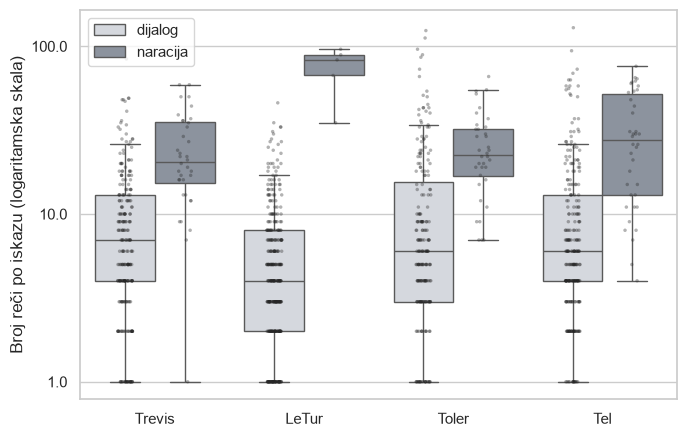

In [62]:
KRATKO = {'Taxi Driver': 'Trevis', 'Light Sleeper': 'LeTur',
          'First Reformed': 'Toler', 'The Card Counter': 'Tel'}
PUNO = {'Taxi Driver': 'Trevis (Taksista)', 'Light Sleeper': 'LeTur (Fatalna nesanica)',
          'First Reformed': 'Toler (Iskušenik)', 'The Card Counter': 'Tel (Kockar)'}
NARACIJA = Patch(facecolor='0.55', alpha=0.3, label='naracija')

sns.set_theme(style='whitegrid')
plt.rcParams.update({'font.size': 11})

d['mod'] = d['type'].map({'dialogue': 'dijalog', 'voice_over': 'naracija'})

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=d, x='film', y='word_count', hue='mod',
            palette=["#d4d7df", "#8992a1"], showfliers=False, ax=ax)
# pojedinačni iskazi preko kutija, da se vidi veličina uzorka
sns.stripplot(data=d, x='film', y='word_count', hue='mod',
              dodge=True, size=2.5, alpha=.35, palette=['0.15', '0.15'],
              legend=False, ax=ax)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.set_xticks(range(4))
ax.set_xticklabels([KRATKO[f] for f in red])
ax.set_ylabel('Broj reči po iskazu (logaritamska skala)')
ax.set_xlabel('')
ax.legend(title='')
fig.tight_layout()
fig.savefig('slika_6_2.png', dpi=300)


## 4. Preprocesiranje

Od ovog mesta radi se sa obrađenim tekstom. Sve što sledi odnosi se na leksičke mere i mere ključnosti; sentiment i emocije su već ocenjeni nad sirovim iskazima.

Tokenizacija je urađena regularnim izrazom koji token definiše kao niz slova, uz  apostrof unitar reči, pa skraćeni oblici poput 'don't' ostaju celi. Pre toga se spajaju reči prelomljene crticom preko dva reda, a dvostruka crtica, kojom scenario obeležava prekid u govoru, zamenjuje se razmakom.

Tekst se čuva u dva sloja. Pun sloj ('tok') zadržava sve tokene i na njemu se računaju mere koje se tiču zamenica, negacije i skraćenih oblika. Sadržajni sloj ('tok_sadrzaj') nastaje uklanjanjem zaustavnih reči, vlastitih imena i jednoslovnih tokena i koristi se za analizu vokabulara.

NLTK lista zaustavnih reči menjana je na dva mesta. Negacije su vraćene u tekst, jer nose značenje bitno za ovo istraživanje. Krnji oblici tima 'don' ili 'didn' izbačeni su iz liste, pošto nastaju samo pri tokenizaciji koja reč deli na apostrofu, kakva se ovde ne koristi.

Lista vlastitih imena je popunjena kroz dva prolaza. Postupak je opisan uz ćeliju sa kandidatima za imena. Kontrolna tvrdnja na kraju fiksira ukupan broj tokena na 13.660, tako da svaka naknadna izmena pravila tokenizacije odmah postane vidljiva.

In [63]:
TOKEN = re.compile(r"[a-z]+(?:'[a-z]+)?")

# NLTK lista se čisti od negacije i od krnjih oblika tipa 'don', 'didn', koji nastaju samo kod tokenizacije koja se ne koristi
NEGACIJA = {'no', 'not', 'nor' ,'never', 'nothing', 'none', 'nobody', 'nowhere',
            "don't", "didn't", "doesn't", "can't", "won't", "wouldn't", "couldn't",
            "shouldn't", "isn't", "aren't", "wasn't", "weren't", "haven't",
            "hasn't", "hadn't", "ain't", "mustn't", "needn't"}


KRNJI = {'don', 'didn', 'doesn', 'won', 'wouldn', 'couldn', 'shouldn', 'isn', 
         'aren', 'wasn', 'weren', 'haven', 'hasn', 'hadn', 'ain', 'mustn', 'needn'}
ZAUSTAVNE = set(stopwords.words('english')) - NEGACIJA - KRNJI

IMENA = {
    # Taxi Driver
    'travis', 'betsy', 'sport' ,'iris', 'palantine', 'wizard', 'wiz', 'melio',
    # Light Sleeper
    'letour',  'robert', 'ann', 'jost', 'jeer', 'tis', 'marianne',
    # First Reformed
    'michael', 'mary' ,'balq', 'joel', 'mensana',
    # The Card Counter
    'cirk', 'gordo', 'linda', 'alex', 'rodgers', 'baufort',
    # Zajednička
    'john', 'ed'
} # prazno u prvom prolazu, popunjeno u drugom.

def tokeni(tekst):
    """ Pun sloj. Prelom reda iz PDF-a se spaja, '--' je prekid u govoru."""
    t = re.sub(r'(?<=[A-Za-z])- (?=[a-z])', '-', str(tekst)).replace('--', ' ')
    return TOKEN.findall(t.lower())

def sadrzajni(toks):
    """ Sadržajni sloj: bez zaustavnih reči, po izboru i bez vlastitih imena"""
    return [w for w in toks if w not in ZAUSTAVNE and w not in IMENA and len(w) > 1]

d = pd.read_csv('all_lines_scored.csv')
red = ['Taxi Driver', 'Light Sleeper', 'First Reformed', 'The Card Counter']
d['film'] = pd.Categorical(d['film'], categories=red, ordered=True)

d['tok'] = d['line'].map(tokeni)
d['tok_sadrzaj'] = d['tok'].map(sadrzajni)

assert d['tok'].map(len).gt(0).all(), 'neki iskaz je ostao bez tokena'
assert d['tok'].map(len).sum() == 13660, 'promenio se broj tokena'
print('tokena:', d.tok.map(len).sum(), '| sadržajnih:', d.tok_sadrzaj.map(len).sum())
print('zaustavnih reči:', len(ZAUSTAVNE), '| imena u listi:', len(IMENA))



tokena: 13660 | sadržajnih: 6810
zaustavnih reči: 162 | imena u listi: 28


6.3. Leksički profil četvorice

Za svaki poduzorak, određen protagonistom i modom, računa se profil od dvanaest vrednosti.

Bogatstvo rečnika mereno je MATTR-om na prozoru od 50 tokena i udelom hapaksa na uzorcima od 350 tokena, kao prosek sto nasumičnih izvlačenja uz zadato seme. Obe mere su birane zato što umanjuj zavisnost od dužine teksta, koja je kod ovog korpusa velika prepreka: poduzorci se razlikuju i po redu veličine. Kada poduzorak ima manje tokena od prozora ili od veličine uzorka, mera se ne računa i vrednost ostaje prazna. Iz tog razloga u tabeli nedostaju vrednosti za naraciju kod LeTura.

Uz to se računaju prosečna dužina reči, leksička gustina kao udeo sadržajnih tokena, udeo skraćenih oblika i udeo negacija. Posebno se izdvajaju zamenice prvog lica jednine, drugog lica i prvog lica množine, izražene na sto tokena, pošto se preko njih pitanje samofokusiranosti i obraćanja sagovorniku iz teorijskog dela dovodi u vezu sa merljivim podatkom. Uz udeo prvog lica množine navodi se i apsolutni broj, jer su vrednosti male i procenat sam po sebi zavarava.

In [64]:
PRVO = {'i', "i'm", "i'd", "i'll", "i've", 'me', 'my', 'mine', 'myself'}
DRUGO = {"you", "you're", "you'd", "you'll", "you've", "your", "yours", "yourself"}
MNOZINA = {'we', "we're", "we'd", "we'll", "we've", 'us', 'our', 'ours', 'ourselves'}

def mattr(toks, prozor=50):
    if len(toks) < prozor:
        return np.nan
    return float(np.mean([len(set(toks[i:i + prozor])) / prozor for i in range(len(toks) - prozor + 1)]))

# uzorak fiksne veličine, jer udeo hapaksa inače opada sa dužinom teksta
def hapaks(toks, n=350, izvlacenja=100, seed=100):
    """Udeo hapaksa na uzorku fiksne veličine, prosek više izvlačenja."""
    if len(toks) < n:
        return np.nan
    v = []
    rng = np.random.default_rng(seed)
    for _ in range(izvlacenja):
        u = rng.choice(toks, size=n, replace=False)
        br = Counter(u)
        v.append(sum(1 for w, k in br.items() if k==1)/ len(br))
    return float(np.mean(v))

def profil(g):
    tok = [w for ts in g.tok for w in ts]
    sadr = [w for ts in g.tok_sadrzaj for w in ts]
    c = Counter(tok)
    na100 = lambda S: 100 * sum(c[w] for w in S) / len(tok)
    return pd.Series({
        'iskaza': len(g),
        'tokena': len(tok),
        'MATTR': mattr(tok),
        'hapaksi': hapaks(tok),
        'duž. reči': np.mean([len(w) for w in tok]),
        'leks. gustina': len(sadr) / len(tok),
        'kontrakcije': 100 * sum(1 for w in tok if "'" in w) / len(tok),
        'negacija': na100(NEGACIJA),
        'prvo lice': na100(PRVO),
        'drugo lice': na100(DRUGO),
        'mi': na100(MNOZINA),
        # uz procenat i apsolutni broj, jer su vrednosti male i procenat zavarava
        'mi (n)': sum(c[w] for w in MNOZINA),
    })

t63 = d.groupby(['film', 'type'], observed=True).apply(profil, include_groups=False)
print(t63.round(2).to_string())
d['prvo_n'] = d['tok'].map(lambda ts: sum(w in PRVO for w in ts))
print(d.groupby(['film', 'type'], observed=True)['prvo_n'].mean().round(2))

                             iskaza  tokena  MATTR  hapaksi  duž. reči  leks. gustina  kontrakcije  negacija  prvo lice  drugo lice    mi  mi (n)
film             type                                                                                                                            
Taxi Driver      dialogue     239.0  2382.0   0.77     0.70       3.77           0.50         6.09      4.07       8.61        4.66  0.17     4.0
                 voice_over    36.0   877.0   0.80     0.74       4.03           0.52         2.85      3.19       7.30        1.03  0.11     1.0
Light Sleeper    dialogue     341.0  2126.0   0.80     0.73       3.97           0.49         7.76      3.53       9.41        6.16  1.32    28.0
                 voice_over     5.0   368.0   0.85     0.73       4.10           0.51         5.16      2.17       4.35        3.26  0.00     0.0
First Reformed   dialogue     212.0  2830.0   0.81     0.75       4.25           0.48         3.64      2.86       4.42     

### Kandidati za vlastita imena

Ćelija pripada prvom prolazu kroz korpus, iako u notebook-u stoji posle ćelije koja imena već koristi. Prikupljaju se reči pisane velikim slovom koje se ne nalaze na početku rečenice, kao kandidati za vlastita imena. Lista se zatim pregleda ručno i upisuje u skup 'IMENA' u ćeliji sa preprocesiranjem, pošto automatska ocena na tako malom korpusu pravi previše grešaka u oba smera.

Imena se uklanjaju samo iz sadržajnog sloja. Bez toga bi frekvencijske i keyness liste bile popunjene imenima sporednih likova, koja govore o zapletu, a ne o jeziku protagoniste.

In [65]:
kand = Counter()
for tekst in d['line'].astype(str):
    for rec in re.split(r'(?<=[.!?])\s+', tekst):
        for w in re.findall(r"[A-Za-z][a-zA-Z']*", rec)[1:]:
            if w[0].isupper():
                kand[w.lower().strip("'")] += 1

for w, k in kand.most_common():
    if k>= 2 and w not in {'i', "i'm", "i'd", "i'll", "i've"}:
        print(f'{k:3d} {w}')

 19 god
 10 betsy
 10 michael
  8 gordo
  7 sport
  7 john
  7 cirk
  6 iris
  6 life
  6 balq
  6 weight
  5 park
  5 d
  5 abundant
  5 reformed
  5 tell
  5 kid
  4 k
  4 god's
  4 t
  4 c
  4 jesus
  4 mary
  4 first
  4 linda
  4 river
  4 ghraib
  3 sir
  3 travis
  3 palantine
  3 tv
  3 u
  3 army
  3 new
  3 day
  3 letour
  3 robert
  3 jost
  3 ed
  3 tis
  3 sunday
  3 holy
  3 s
  3 american
  3 michael's
  3 blackjack
  3 city
  3 baufort
  3 turn
  3 gitmo
  3 abu
  2 bronx
  2 broadway
  2 wizard
  2 bell
  2 president
  2 street
  2 ave
  2 here
  2 melio
  2 wiz
  2 secret
  2 service
  2 man
  2 l
  2 e
  2 york
  2 ann
  2 jeer
  2 canada
  2 church
  2 you
  2 a
  2 governor
  2 industries
  2 joel
  2 mensana
  2 he
  2 his
  2 monday
  2 ground
  2 slippery
  2 asian
  2 atlantic
  2 foxwoods
  2 delaware
  2 northwest
  2 the
  2 iowa
  2 alex
  2 flop
  2 noise
  2 rodgers
  2 sere
  2 not
  2 world
  2 series


## 6.4. Zajednički vokabular sve četvorice

Izdvajaju se sadržajne reči koje se javljaju kod sve četvorice protagonista, sa najmanje dva pojavljivanja kod svakog. Prag postoji zato što bi se sa jednim ponavljanjem u listu upisale i slučajne podudarnosti.

Učestalosti se izražavaju na hiljadu sadržajnih tokena, jer su poduzorci nejednaki i apsolutni brojevi se ne mogu porediti. Uz tabelu navodi se i pokrivenost - koliki udemo sadržajnih tokena svakog protagoniste otpada na ovaj zajednički skup.

In [66]:
PRAG = 2

br = {f: Counter(w for ts in d.loc[d.film == f, 'tok_sadrzaj'] for w in ts) for f in red}
uk = {f: sum(br[f].values()) for f in red}

zajednicke = sorted(w for w in set.intersection(*[set(br[f]) for f in red])
                    if all(br[f][w] >= PRAG for f in red))

t64 = pd.DataFrame(
    {f: [round(1000 * br[f][w] / uk[f], 2) for w in zajednicke] for f in red}, index=zajednicke)
t64['ukupno'] = [sum(br[f][w] for f in red) for w in zajednicke]
t64 = t64.sort_values('ukupno', ascending=False)

pokrivenost = pd.Series(
    {f: round(100 * sum(br[f][w] for w in zajednicke) / uk[f], 1) for f in red})

print(f'zajedničke reči (prag {PRAG}): {len(zajednicke)}')
print(t64.to_string())
print()
print('pokrivenost sadržajnih tokena, %:')
print(pokrivenost.to_string())

zajedničke reči (prag 2): 58
           Taxi Driver  Light Sleeper  First Reformed  The Card Counter  ukupno
not               9.73          14.52           18.38             11.08      91
no               19.46           9.68           13.51              7.23      84
don't            18.25          18.55            7.57              7.71      83
like             16.42          12.90            4.86             13.49      80
know             14.60          19.35            8.11              6.26      76
go               12.77          12.90            2.70              5.30      53
want              7.91           4.84            7.03              9.63      52
one              13.38           6.45            3.78              6.26      50
got              11.56          10.48            2.16              6.74      50
get              15.21           6.45            1.08              3.85      43
see               5.47           7.26            5.95              4.82      39
life       

### Neravnomernost raspodele

Pripadnost zajedničkom skupu ne znači da su reči i podjednako zastupljene. Za svaku reč se računa G^2 kao odstupanje stvarne raspodele od one koja bi bila srazmerna veličini poduzorka, uz odnos najviše i najniže stope i ime protagoniste sa najvišom.

Pošto se odjenom testira pedeset osam reči, primenjuje se korekcija po Benjamini-Hočbergu. Pripazuju se samo reči sa najmanje dvadeset pojavljivanja u korpusu, jer su kod manjih brojeva i G^2 i odnos stopa nestabilni.

In [67]:
def neravnomernost(zajednicke, br, uk):
    """G^2 po reči: koliko raspodela odstupa od srazmerne veličini poduzorka."""
    UKUPNO = sum(uk.values())
    redovi = []
    for w in zajednicke:
        o = np.array([br[f][w] for f in red],float)
        e = o.sum() * np.array([uk[f] for f in red]) / UKUPNO
        # nula u o nije moguća: zajedničke reči imaju bar PRAG pojavljivanja kod svakog
        G = 2 * np.sum(o * np.log(o / e))
        stope = [1000 * br[f][w] / uk[f] for f in red]
        redovi.append({'reč': w, 'ukupno': int(o.sum()), 'G2': G,
                    'p': chi2.sf(G, 3), 'odnos': max(stope) / min(stope),
                    'najviši': red[int(np.argmax(stope))]})
    t = pd.DataFrame(redovi).sort_values('G2', ascending=False).reset_index(drop=True)
    # Benjamini-Hochberg, jer se testira 58 reči odjednom
    m = len(t)
    t['p_BH'] = np.minimum.accumulate(
        np.minimum(1, t['p'] * m / np.arange(1, m + 1))[::-1])[::-1]
    return t

t64n = neravnomernost(zajednicke, br, uk)
print(t64n[t64n.p_BH < 0.05].round(3).to_string(index=False))
    
zajednicke_tab = (t64.rename_axis('reč').reset_index()
                  .merge(t64n[['reč','G2','p','p_BH','odnos','najviši']], on='reč')
                  .round(3))

with pd.ExcelWriter('zajednicke_reci.xlsx') as w:
    zajednicke_tab.to_excel(w, sheet_name='Zajedničke reči', index=False)
    pokrivenost.rename('pokrivenost (%)').to_frame().to_excel(w, sheet_name='Pokrivenost')



  reč  ukupno     G2     p  odnos        najviši  p_BH
  get      43 29.331 0.000 14.066    Taxi Driver 0.000
 well      30 18.126 0.000  6.752    Taxi Driver 0.009
   go      53 17.955 0.000  4.774  Light Sleeper 0.009
 come      29 16.294 0.001  9.538 First Reformed 0.014
don't      83 15.524 0.001  2.451  Light Sleeper 0.016
 know      76 14.713 0.002  3.091  Light Sleeper 0.020
  got      50 14.340 0.002  5.345    Taxi Driver 0.021
 look      21 13.857 0.003  9.208  Light Sleeper 0.023
 like      80 12.963 0.005  3.376    Taxi Driver 0.030
   no      84 11.891 0.008  2.694    Taxi Driver 0.045


## 6.5. Distinktivni vokabular: svaki naspram ostalih

Mera ključnosti, računata kao G^2 za svakog protagonistu naspram preostale trojice, koji ovde služe kao referentni korpus. Zadržavaju se samo prekomerno zastupljene reči, dakle one čija je stopa kod protagoniste viša neko kod ostalih; podzastupljenost je zasebno pitanje i ovde se ne razmatra.

Prag od pet pojavljivanja isključuje reči koje bi ušle u listu samo zato što ih niko drugi ne koristi. I ovde se primenjuje korekcija po Benjamini-Hočbergu, pošto se testira nekoliko stotina reči odjednom. Rezultat se ne čita kao rang-lista: svaka istaknuta reč traži proveru u kontekstu u kojem se zaista javlja.

In [68]:
PRAG_LIK = 5 

def distinktivne(br, uk, prag=PRAG_LIK):
    """Keyness: G^2 jedan lik naspram ostale trojice, samo prekomerno zastupljene reči."""
    redovi = []
    for f in red:
        ostali = [g for g in red if g != f]
        n_ost = sum(uk[g] for g in ostali)
        for w, k in br[f].items():
            if k < prag:
                continue
            k_ost = sum(br[g][w] for g in ostali)
            s_lik, s_ost = 1000 * k / uk[f], 1000 * k_ost / n_ost
            if s_lik <= s_ost:          # jednosmerno: traže se samo reči kojima je lik prekomerno zastupljen
                continue
            o = np.array([k, k_ost], float)
            e = (k + k_ost) * np.array([uk[f], n_ost], float) / (uk[f] + n_ost)
            G = 2 * sum(x * np.log(x / y) for x, y in zip(o, e) if x > 0)
            redovi.append({'lik': f, 'reč': w, 'n': k, 'stopa': s_lik, 'ostali': s_ost, 'G2': G, 'p': chi2.sf(G, 1)})
    t = pd.DataFrame(redovi).sort_values('G2', ascending=False).reset_index(drop=True)
    m = len(t)
    t['p_BH'] = np.minimum.accumulate(
        np.minimum(1, t['p'] * m / np.arange(1, m + 1))[::-1])[::-1]
    return t

t65 = distinktivne(br, uk)

assert t65['G2'].notna().all(), 'G2 sadrži nan'
assert (t65['stopa'] > t65['ostali']).all(), 'ušla je podzastupljena reč'
print(f'testirano reči: {len(t65)} | preživi BH 0,05: {(t65.p_BH < 0.05).sum()}')
for f in red:
    print('###', f)
    print(t65[t65.lik == f].head(10)
          [['reč', 'n', 'stopa', 'ostali', 'G2', 'p_BH']].round(3).to_string(index=False))

t65[t65.p_BH < 0.05].round(3).to_excel('distinktivne_reci.xlsx', index=False)



testirano reči: 210 | preživi BH 0,05: 98
### Taxi Driver
   reč  n  stopa  ostali     G2  p_BH
   mam 10  6.083   0.000 28.425   0.0
   cab 10  6.083   0.000 28.425   0.0
 clean  9  5.474   0.000 25.583   0.0
   hey  9  5.474   0.000 25.583   0.0
   get 25 15.207   3.484 22.544   0.0
people 19 11.557   1.936 22.171   0.0
 can't 12  7.299   0.581 20.756   0.0
  taxi  7  4.258   0.000 19.898   0.0
  work 12  7.299   0.774 18.326   0.0
  well 18 10.949   2.323 17.416   0.0
### Light Sleeper
     reč  n  stopa  ostali     G2  p_BH
anything 15 12.097   1.975 20.095 0.000
 jealous  5  4.032   0.000 17.033 0.000
    kiss  5  4.032   0.000 17.033 0.000
    look 11  8.871   1.795 12.428 0.002
    love  5  4.032   0.180 12.028 0.002
   years 10  8.065   1.616 11.397 0.003
     use  5  4.032   0.359  9.461 0.007
    last  7  5.645   1.077  8.313 0.012
    know 24 19.355   9.336  7.866 0.014
   sorry  5  4.032   0.718  6.275 0.030
### First Reformed
     reč  n  stopa  ostali     G2  p_BH
     go

## 6.6. Poređenje transformerskog i leksikonskog pristupa

Slaganje dva pristupa sentimentu, izraženo kao udeo podudarnih oznaka i Koenova kapa, uz unakrsnu tabelu koja pokazuje i smer neslaganja.

Slaganje se dalje razlaže po razredima dužine iskaza i po modu. Razlog je pretpostavka da kratki iskazi, kojih u dijalogu ima najviše, daju premalo leksičkih signala leksikonskom pristupu, pa da slaganje raste sa dužinom. Rezultat ovog odeljka čita se kao nalaz o granicama metode, a ne kao izbor pristupa koji bolje odgovara tezi.

In [69]:
d['slaze'] = d['sent_label'] == d['vader_label']
kos = [0, 5, 10, 20, 40, 10**6]
d['duzina'] = pd.cut(d['word_count'], kos, labels=['1-5', '6-10', '11-20', '21-40', '41+'])

print(pd.crosstab(d.sent_label, d.vader_label))
print('\nslaganje %:', round(100 * d.slaze.mean(), 1), 
      '| kapa:', round(cohen_kappa_score(d.sent_label, d.vader_label), 3))

print('\nslaganje po dužini:')
print(d.groupby('duzina', observed=True)
      .agg(n=('slaze', 'size'), slaganje=('slaze', lambda x: round(100 * x.mean(), 1))).to_string())

print('\nslaganje po dužini i modu:')
print(d.pivot_table(index='duzina', columns='type', values='slaze',
                    aggfunc=['size', 'mean'], observed=True).round(3).to_string())

vader_label  negative  neutral  positive
sent_label                              
negative          131       53        54
neutral            86      504       252
positive            4       12        62

slaganje %: 60.2 | kapa: 0.316

slaganje po dužini:
          n  slaganje
duzina               
1-5     536      71.5
6-10    254      63.4
11-20   180      45.6
21-40   124      43.5
41+      64      26.6

slaganje po dužini i modu:
           size                mean           
type   dialogue voice_over dialogue voice_over
duzina                                        
1-5         533          3    0.715      0.667
6-10        241         13    0.639      0.538
11-20       149         31    0.423      0.613
21-40        82         42    0.415      0.476
41+          38         26    0.316      0.192


### Uzorak za ručno kodiranje

Za proveru modela izvlači se stratifikovan nasumični uzorak od 80 iskaza, i to 65 iz dijaloga i 15 iz naracije, zasebno za svaki film i mod (Iskušenik 13 + 4, Fatalna nesanica 21 + 3, Taksista 15 + 4, Kocakr 16 + 4). Naracija je namerno zastupljenija nego u korpusu (19% naspram 10%), kako bi slaganje moglo da se izračuna i za ovaj mod.

Iskazi se izvlače funkcijom 'sample' iz biblioteke pandas, uz seme 100, a zatim se istim semenom mešaju. Svaki iskaz dobija oznaku (npr. 'LS-152' za *Light Sleeper*, red 152), a oznake transformerskog modela i VADER-a pretvaraju se u brojeve 1, 2 i 3 (negativno, neutralno, pozitivno). Uzorak se čuva u 'uzorak_seme100.xlsx', odakle se prenosi u tabelu za kodiranje: iskazi idu na list "Kodiranje", a oznake modela na skriveni list "Model", kako bi se kodiralo bez uvida u njih.

In [70]:
d0 = pd.read_csv('all_lines_scored.csv').sort_values(['film', 'line_no'])

STRATUMI = {('First Reformed', 'dialogue'): 13, ('First Reformed', 'voice_over'): 4,
            ('Light Sleeper', 'dialogue'): 21, ('Light Sleeper', 'voice_over'): 3,
            ('Taxi Driver', 'dialogue'): 15, ('Taxi Driver', 'voice_over'): 4,
            ('The Card Counter', 'dialogue'): 16, ('The Card Counter', 'voice_over'): 4}

uzorak = pd.concat([d0[(d0.film == f) & (d0.type == t)].sample(n, random_state=100)
                   for (f, t), n in STRATUMI.items()])
uzorak = uzorak.sample(frac=1, random_state=100)

PREFIKS ={'Light Sleeper': 'LS', 'First Reformed': 'FR',
          'Taxi Driver': 'TD', 'The Card Counter': 'CC'}
OZNAKA = {'negative': 1, 'neutral': 2, 'positive':3}

uzorak['ID'] = uzorak['film'].map(PREFIKS) + '-' + uzorak['line_no'].astype(str)
uzorak['model_sent (1/2/3)'] = uzorak['sent_label'].map(OZNAKA)
uzorak['vader (1/2/3)'] = uzorak['vader_label'].map(OZNAKA)

uzorak[['ID', 'film', 'type', 'word_count', 'line', 'model_sent (1/2/3)', 'vader (1/2/3)']].to_excel('uzorak_seme100.xlsx', index=False)

print(uzorak.groupby(['film', 'type']).size())

film              type      
First Reformed    dialogue      13
                  voice_over     4
Light Sleeper     dialogue      21
                  voice_over     3
Taxi Driver       dialogue      15
                  voice_over     4
The Card Counter  dialogue      16
                  voice_over     4
dtype: int64


## 6.7. Emocionalni profil po narativnom modu

Prosečne verovatnoće po sedam kategorija, za svakog protagonistu i svaki mod, praćene poređenjem naracije i dijaloga na celom korpusu. Radi se sedam testova, po jedan za svaku kategoriju, uz rang-biserijalnu korelaciju kao veličinu efekta i korekciju po Benjamini-Hočbergu.

Poslednji deo ćelije je provera sumnje da model kategoriju iznenađenja dodeljuje na osnovu upitne forme, a ne na osnovu sadržaja. Poredi se prosečna verovatnoća iznenađenja kod iskaza sa upitnikom i bez njega, i navodi udeo upitnih iskaza po modu. Ako se razlika potvrdi, viša vrednost iznenađenja u dijalogu je delom formalni artefakt, a ne nalaz o liku, i tako se i izveštava.

In [71]:
EMO = ['emo_anger', 'emo_disgust', 'emo_fear', 'emo_joy', 'emo_sadness', 'emo_surprise', 'emo_neutral']
NAZ = {'emo_anger': 'bes', 'emo_disgust': 'gađenje', 'emo_fear': 'strah', 'emo_joy': 'radost', 
       'emo_sadness': 'tuga', 'emo_surprise': 'iznenađenje', 'emo_neutral': 'neutralno'}

t67 = (d.groupby(['film', 'type'], observed=True)
       .agg(iskaza=('line', 'size'), **{c: (c, 'mean') for c in EMO})
       .rename(columns=NAZ))

assert len(t67) == 8, 'očekivano osam redova'
assert abs(t67[list(NAZ.values())].sum(axis=1) - 1).max() < 0.01, 'verovatnoće se ne sabiraju'
print(t67.round(3).to_string())

# Sedam testova, naracija naspram dijaloga, ceo korpus
dij, nar = d[d.type == 'dialogue'], d[d.type == 'voice_over']
redovi = []

for c in EMO:
    u, p = mannwhitneyu(nar[c], dij[c])
    redovi.append({'emocija': NAZ[c], 'dijalog': dij[c].mean(), 'naracija': nar[c].mean(),
                   'rb': 2 * u / (len(dij) * len(nar)) - 1, 'p': p})
t67t = pd.DataFrame(redovi).sort_values('p').reset_index(drop=True)
m = len(t67t)
t67t['p_BH'] = np.minimum.accumulate(
    np.minimum(1, t67t['p'] * m / np.arange(1, m + 1))[::-1])[::-1]
print('\n', t67t.round(4).to_string(index=False))

# Provera sumnje da li 'surprise' prati upitnik, a ne emocije
d['upitnik'] = d['line'].astype(str).str.contains(r'\?')
print('\n', d.groupby('upitnik')
      .agg(iskaza=('line', 'size'), iznenađenje=('emo_surprise', 'mean')).round(3).to_string())
print(d.groupby('type')['upitnik'].mean().round(3).to_string())


                             iskaza    bes  gađenje  strah  radost   tuga  iznenađenje  neutralno
film             type                                                                            
Taxi Driver      dialogue       239  0.113    0.105  0.050   0.073  0.078        0.155      0.426
                 voice_over      36  0.099    0.199  0.044   0.046  0.184        0.085      0.343
Light Sleeper    dialogue       341  0.088    0.070  0.050   0.067  0.091        0.180      0.454
                 voice_over       5  0.107    0.116  0.019   0.031  0.030        0.217      0.480
First Reformed   dialogue       212  0.089    0.057  0.070   0.082  0.081        0.166      0.455
                 voice_over      36  0.122    0.062  0.121   0.101  0.136        0.055      0.403
The Card Counter dialogue       251  0.101    0.074  0.034   0.062  0.054        0.171      0.504
                 voice_over      38  0.105    0.093  0.103   0.057  0.027        0.108      0.507

     emocija  dijal

## 6.8. Emocionalne trajektorije kroz narativ

Kretanje sentimenta duž narativne ose, za svakog protagonistu zasebno. Prikazana je razlika verovatnoća pozitivnog i negativnog razreda transformerskog modela i, radi poređenja, VADER-ov compound skor na istoj osi.

Obe krive su uglačane kliznim prosekom preko petnaest iskaza, jer su pojedinačne vrednosti previše skokovite da bi se video obrazac. Isto uglačavanje primenjeno je i na horizontalnu osu, kako bi svaka tačka krive stajala iznad sredine prozora iz kojeg je izračunata. Siva polja označavaju iskaze naracije, tako da se vidi gde se ona u filmu javlja i dali se uz nju kriva pomera.

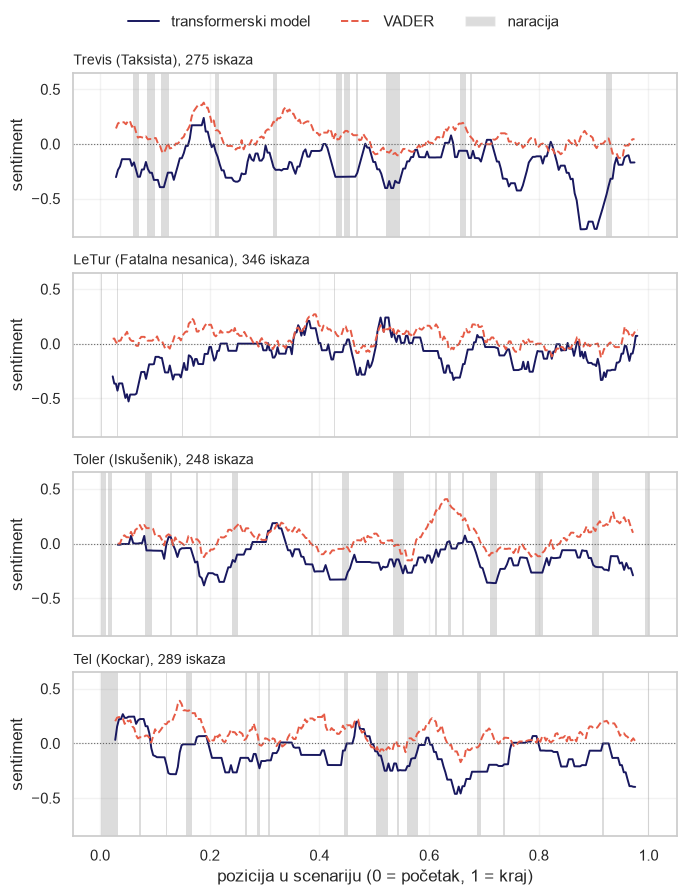

In [72]:
PROZOR = 15

d['polaritet'] = d['sent_positive'] - d['sent_negative']

fig, ose = plt.subplots(4, 1, figsize=(7, 9), sharex=True)
for ax, f in zip(ose, red):
    g = d[d.film == f].sort_values('line_no')
    x = g['rel_position'].rolling(PROZOR, center=True).mean()
    for kol, boja, stil, ime in [('polaritet', "#18185f", '-', 'transformerski model'),
                                 ('vader_compound', "#e65b46", '--', 'VADER')]:
        ax.plot(x, g[kol].rolling(PROZOR, center=True).mean(),
                color=boja, ls=stil, lw=1.4, label=ime)
    pola = 0.5 / len(g) # pola razmaka između iskaza
    for p in g.loc[g.type == 'voice_over', 'rel_position']:
        ax.axvspan(p - pola, p + pola, color='0.55', alpha=0.30, lw=0)
    ax.axhline(0, color='0.4', ls=':', lw=0.8)
    ax.set_ylabel('sentiment')
    ax.set_title(f'{PUNO[f]}, {len(g)} iskaza', loc='left', fontsize=10)
    ax.set_ylim(-0.85, 0.65)
    ax.grid(alpha=0.25)

h, l = ose[0].get_legend_handles_labels()
fig.legend(h + [NARACIJA], l + ['naracija'], loc='upper center', ncol=3,
           frameon=False, bbox_to_anchor=(0.5, 1.0))
ose[-1].set_xlabel('pozicija u scenariju (0 = početak, 1 = kraj)')
fig.tight_layout(rect=(0, 0, 1, 0.96))
fig.savefig('slika_6_8a.png', dpi=300)
plt.show()


### Trajektorija negativnih emocija

Isti prikaz, ali sa tri kategorije modela emocija: bes, gađenje i tuga. Sentiment pokazuje samo smer, dok se ovde vidi koja se vrsta negativnog osećanja menja i na kom mestu u narativu. Vertikalna osa je verovatnoća, pa su vrednosti neposredno uporedive među filmovima.

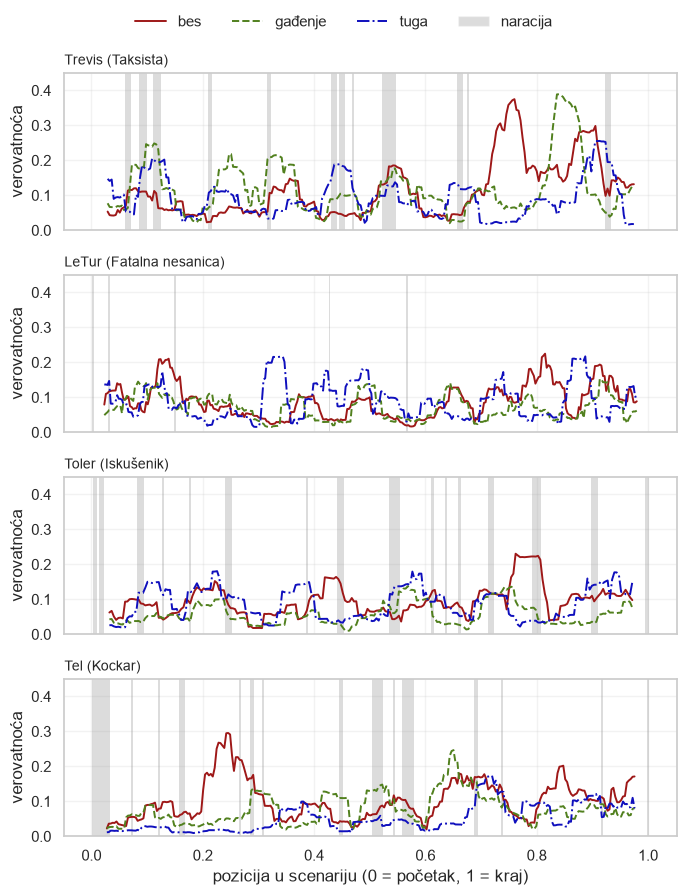

In [73]:
NEG = [('emo_anger', 'bes', "#9e1818", '-'),
       ('emo_disgust', 'gađenje', "#51801e",'--'),
       ('emo_sadness', 'tuga', "#0f0fbd", '-.')]

fig, ose = plt.subplots(4, 1, figsize=(7, 9), sharex=True)
for ax, f in zip(ose, red):
    g = d[d.film == f].sort_values('line_no')
    # i x se uglačava, da tačka krive stoji iznad sredine prozora iz kojeg je izračunata
    x = g['rel_position'].rolling(PROZOR, center=True).mean()
    for kol, ime, boja, stil in NEG:
        ax.plot(x, g[kol].rolling(PROZOR, center=True).mean(), color=boja, ls=stil, lw=1.4, label=ime)
    pola = 0.5 / len(g)
    for p in g.loc[g.type == 'voice_over', 'rel_position']:
        ax.axvspan(p - pola, p + pola, color='0.55', alpha=0.30, lw=0)
    ax.set_ylabel('verovatnoća')
    ax.set_title(PUNO[f], loc='left', fontsize=10)
    ax.set_ylim(0, 0.45)
    ax.grid(alpha=0.25)

h, l = ose[0].get_legend_handles_labels()
fig.legend(h + [NARACIJA], l + ['naracija'], loc='upper center', ncol=4,
           frameon=False, bbox_to_anchor=(0.5, 1.0))
ose[-1].set_xlabel('pozicija u scenariju (0 = početak, 1 = kraj)')
fig.tight_layout(rect=(0, 0, 1, 0.96))
fig.savefig('slika_6_8b.png', dpi=300)
plt.show()



### Opisne mere trajektorija

Da opis trajektorija ne bi počivao samo na izgledu grafika, za svakog protagonistu računa se prosečan polaritet transformerskog modela (razlika verovatnoća pozitivne i negativne klase) za svaku trećinu scenarija i za ceo scenario. Trećine su određene prema relativnoj poziciji iskaza. Pored toga, računa se udeo tačaka pokretnog proseka koje su ispod nule i korelacija između krivih pokretnog proseka transformerskog modela i VADER-a. Za bes, gađenje i tugu beleže se najviša vrednost pokretnog proseka i pozicija na kojoj se ona javlja. Pokretni prosek računa se na istom prozoru od 15 iskaza kao na graficima.

In [74]:
redovi, vrhovi = [], []
for f in red:
    g = d[d.film == f].sort_values('line_no')
    x = g['rel_position'].rolling(PROZOR, center=True).mean()
    pol_k = g['polaritet'].rolling(PROZOR, center=True).mean()
    vad_k = g['vader_compound'].rolling(PROZOR, center=True).mean()
    trecina = pd.cut(g['rel_position'], [0, 1/3, 2/3, 1],
                     labels=['1. trećina', '2. trećina', '3. trećina'])
    redovi.append({'protagonista': PUNO[f],
                   **g.groupby(trecina, observed=True)['polaritet'].mean().to_dict(),
                   'ceo scenario': g['polaritet'].mean(),
                   'kriva < 0 (%)': 100 * (pol_k.dropna() < 0).mean(),
                   'r (transformer, VADER)': pol_k.corr(vad_k)})
    for kol, ime in [('emo_anger', 'bes'), ('emo_disgust', 'gađenje'), ('emo_sadness', 'tuga')]:
        k = g[kol].rolling(PROZOR, center=True).mean()
        vrhovi.append({'protagonista': PUNO[f], 'emocija': ime,
                       'vrh': k.max(), 'pozicija': x[k.idxmax()]})

print(pd.DataFrame(redovi).round(2).to_string(index=False))
print()
print(pd.DataFrame(vrhovi).round(2).to_string(index=False))

            protagonista  1. trećina  2. trećina  3. trećina  ceo scenario  kriva < 0 (%)  r (transformer, VADER)
       Trevis (Taksista)       -0.17       -0.16       -0.29         -0.21          91.95                    0.35
LeTur (Fatalna nesanica)       -0.17       -0.05       -0.09         -0.10          75.00                    0.50
       Toler (Iskušenik)       -0.08       -0.15       -0.20         -0.14          86.32                    0.55
            Tel (Kockar)       -0.06       -0.11       -0.16         -0.11          78.55                    0.40

            protagonista emocija  vrh  pozicija
       Trevis (Taksista)     bes 0.37      0.76
       Trevis (Taksista) gađenje 0.39      0.84
       Trevis (Taksista)    tuga 0.26      0.91
LeTur (Fatalna nesanica)     bes 0.22      0.82
LeTur (Fatalna nesanica) gađenje 0.15      0.91
LeTur (Fatalna nesanica)    tuga 0.22      0.89
       Toler (Iskušenik)     bes 0.23      0.76
       Toler (Iskušenik) gađenje 0.14      0.

### Ponovljivost

Nasumičnost se javlja samo kod udela hapaksa i izvlačenja uzorka za ručno kodiranje, gde je seme zadato, pa su vrednosti ponovljive. Kontrolne tvrdnje kroz notebook fiksiraju tri broja: 1.158 iskaza, 13.660 tokena i 57 blokova naracije. Ako se neki od njih promeni posle izmene pravila, promena je posledica te izmene, a ne slučajnosti.

Ono što nije automatizovano navedeno je izričito: lista vlastitih imena sastavljena je ručno iz liste kandidata, a jedna replika u scenariju za *Kockara* bila je pogrešno pripisana drugom liku i ispravljena je pre analize.

Izlaz ocenjivanja ('all_lines_scored.csv'), kao i nasumični uzorak ('uzorak_seme100.xlsx') priloženi su uz notebook, pa se svi koraci od odeljka 6.1 naniže mogu ponoviti bez preuzimanja modela i bez pristupa scenarijima.